# Optativa III: Ciencia de Datos
## Revisión técnica avanzada — Transformación de datos e integración total sobre Amazon

**Universidad de Especialidades UNE · Plantel Centro**
**Ingeniería en Computación · 9.º semestre · Semana 4 · Actividad integradora avanzada**

---

### Propósito

Esta actividad de **nivel avanzado** integra la **transformación de datos** (Semana 4) con todo el análisis estadístico del curso (Semanas 2 y 3), sobre el dataset real de **Amazon**. Aquí demostrarás que dominas el flujo profesional completo: **transformar correctamente los datos → analizarlos → modelarlos → interpretar el efecto de cada transformación en los resultados**.

El foco está en algo que los principiantes ignoran: **las transformaciones no son cosméticas, cambian lo que un modelo puede aprender e interpretar**. Verás, por ejemplo, por qué estandarizar permite comparar la importancia de las variables, o por qué codificar mal una categoría arruina un análisis.

Responderás **50 preguntas ✍️** de análisis y de modificación de código, con complejidad alta.

### El dataset

`amazon.csv` — Amazon Sales Dataset (1,465 productos limpios: category, discounted_price, actual_price, discount_percentage, rating, rating_count). Súbelo a Colab antes de empezar.

### Cómo trabajar

Ejecuta cada celda en orden con **Shift + Enter**, responde las preguntas ✍️, completa los retos y entrega en Classroom. El nivel es alto: prioriza la interpretación sobre la ejecución mecánica.


---
# FASE 1 — Transformaciones fundamentales

## Paso 0 — Carga y perfil de variables


In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.linear_model import LinearRegression

pd.set_option("display.max_columns", None)
np.random.seed(42)

df = pd.read_csv("amazon.csv")
print("Dimensiones:", df.shape)
print("\nTipos:")
print(df.dtypes)
df.head()

Dimensiones: (1465, 8)

Tipos:
product_id              object
product_name            object
category                object
discounted_price       float64
actual_price           float64
discount_percentage    float64
rating                 float64
rating_count           float64
dtype: object


,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count
0,B0416836764,Producto Computers&Accessories 0,Computers&Accessories,874.0,4163.0,79.0,4.1,8922.0
1,B0490841834,Producto Car&Motorbike 1,Car&Motorbike,510.0,1021.0,50.0,4.0,13556.0
2,B0128388400,Producto Home&Kitchen 2,Home&Kitchen,1128.0,1880.0,40.0,3.2,1326.0
3,B0269299842,Producto Computers&Accessories 3,Computers&Accessories,1301.0,2711.0,52.0,3.7,5650.0
4,B0199799663,Producto Electronics 4,Electronics,4168.0,6833.0,39.0,4.1,3386.0


> ✍️ **1.** Clasifica cada columna del dataset: ¿cuáles son numéricas continuas, cuáles categóricas nominales y cuáles podrían tratarse como ordinales? Justifica.

> ✍️ **2.** Las variables `actual_price` (miles) y `rating` (1-5) están en escalas radicalmente distintas. Menciona dos tipos de análisis o algoritmos donde esta diferencia de escala causaría problemas si no la corrigiéramos.

> ✍️ **3.** Antes de transformar, ¿por qué es importante conocer la **distribución** de cada variable? (Pista: la transformación adecuada depende de si la variable es sesgada, tiene outliers, etc.)

**Respuestas:**

1. `discounted_price`, `actual_price`, `discount_percentage`, `rating` y `rating_count` son numéricas. `product_id`, `product_name` y `category` son categóricas nominales; el nombre y el identificador no tienen orden. `rating` también puede tratarse como ordinal porque sus valores representan niveles ordenados de valoración, aunque numéricamente se usa como continua en algunos análisis.

2. La diferencia de escala afecta a métodos basados en distancias, como k-means o k-NN, y a modelos regularizados o de descenso de gradiente, como regresión lineal con Ridge/Lasso y redes neuronales. La variable con valores mayores dominaría el cálculo.

3. La distribución permite detectar sesgo, outliers, valores imposibles y concentraciones. Con esa información se elige la transformación adecuada: logaritmo para sesgo a la derecha, estandarización para llevar escalas a media 0 y desviación 1, o métodos robustos si hay muchos outliers.


## Paso 1 — Normalización vs estandarización: comparación técnica


ORIGINAL   -> min: 100  max: 19137  media: 2566
NORMALIZADO-> min: 0.000  max: 1.000  media: 0.130
ESTANDARIZ.-> min: -1.076  max: 7.233  media: 0.000


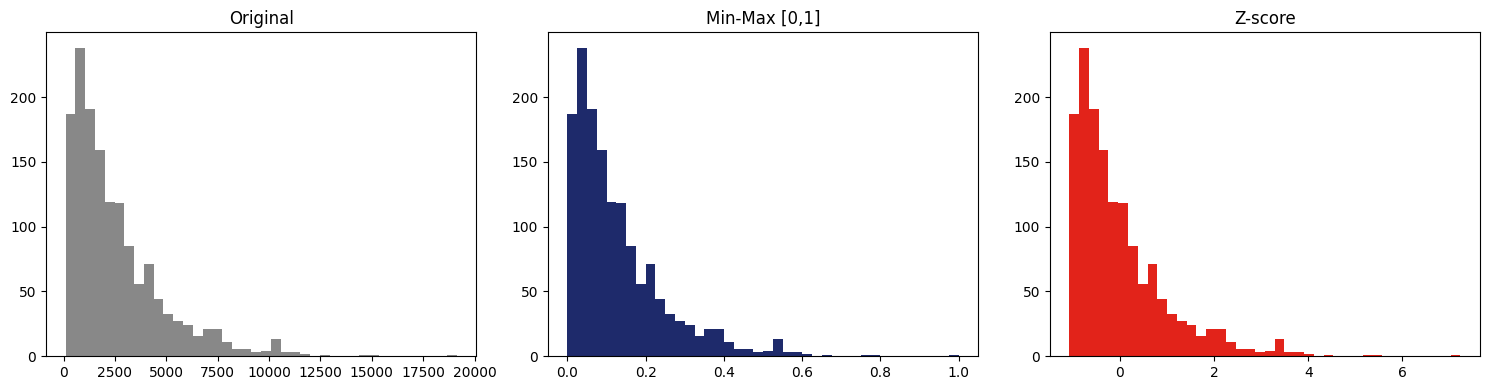

In [13]:
# Aplicamos AMBAS transformaciones a actual_price para compararlas
df["precio_norm"] = MinMaxScaler().fit_transform(df[["actual_price"]])
df["precio_z"] = StandardScaler().fit_transform(df[["actual_price"]])

print("ORIGINAL   -> min: {:.0f}  max: {:.0f}  media: {:.0f}".format(
    df["actual_price"].min(), df["actual_price"].max(), df["actual_price"].mean()))
print("NORMALIZADO-> min: {:.3f}  max: {:.3f}  media: {:.3f}".format(
    df["precio_norm"].min(), df["precio_norm"].max(), df["precio_norm"].mean()))
print("ESTANDARIZ.-> min: {:.3f}  max: {:.3f}  media: {:.3f}".format(
    df["precio_z"].min(), df["precio_z"].max(), df["precio_z"].mean()))

fig, axes = plt.subplots(1, 3, figsize=(15,4))
axes[0].hist(df["actual_price"], bins=40, color="#888"); axes[0].set_title("Original")
axes[1].hist(df["precio_norm"], bins=40, color="#1e2a6b"); axes[1].set_title("Min-Max [0,1]")
axes[2].hist(df["precio_z"], bins=40, color="#e2231a"); axes[2].set_title("Z-score")
plt.tight_layout(); plt.show()

> ✍️ **4.** Compara los tres histogramas. ¿La **forma** de la distribución cambió con alguna transformación, o solo cambió la escala del eje? ¿Qué implica esto?

> ✍️ **5.** La media del salario normalizado NO es 0.5, sino menor. ¿Por qué? (Pista: la distribución de precios está sesgada a la derecha, y Min-Max no corrige el sesgo.)

> ✍️ **6.** Ni la normalización ni la estandarización corrigen el **sesgo** de una distribución. Investiga: ¿qué transformación SÍ reduce el sesgo de una variable como el precio? (Pista: logaritmo.)

**Respuestas:**

4. La forma se conserva: las tres distribuciones siguen sesgadas a la derecha. Solo cambia la escala del eje, por lo que normalizar o estandarizar no modifica las relaciones ni corrige el sesgo.

5. Min-Max transforma con `(x - mínimo) / (máximo - mínimo)`. Como la mayoría de los precios está cerca del mínimo y pocos valores muy altos extienden el rango, la mayoría queda por debajo de 0.5; por eso la media es 0.130.

6. Una transformación logarítmica, como `log1p(x)`, comprime los valores grandes y reduce el sesgo a la derecha. También pueden usarse Box-Cox o Yeo-Johnson según las restricciones de los datos.


### 🔧 Reto 1 — Transformación logarítmica

Crea `precio_log` aplicando `np.log1p(actual_price)` (logaritmo). Grafica su histograma y compáralo con el original. ¿Se ve más simétrico?


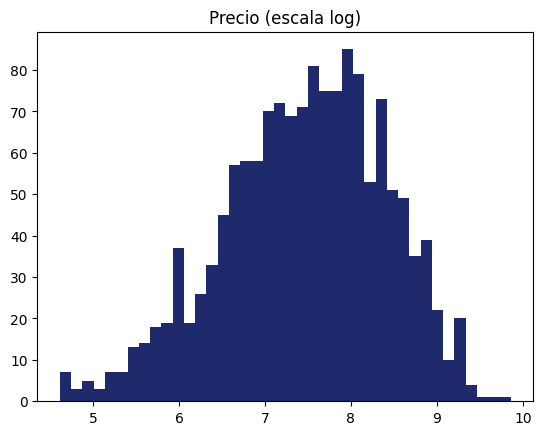

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("amazon .csv")

df["precio_log"] = np.log1p(df["actual_price"])
plt.hist(df["precio_log"], bins=40, color="#1e2a6b")
plt.title("Precio (escala log)"); plt.show()

> ✍️ **7.** ¿La transformación logarítmica hizo la distribución del precio más simétrica? ¿Por qué en ciencia de datos se aplica log a variables como precios, ingresos o poblaciones?

> ✍️ **8.** ¿Cuándo preferirías estandarización (Z-score) sobre normalización (Min-Max)? Da un criterio claro basado en la presencia de outliers.

**Respuestas:**

7. Sí, el logaritmo hace la distribución más simétrica al comprimir los precios altos. Se usa en precios, ingresos y poblaciones porque reduce el efecto de valores extremos, estabiliza la variabilidad y permite interpretar cambios relativos o porcentuales.

8. Preferiría Z-score cuando hay outliers moderados o cuando no necesito un intervalo fijo. Min-Max depende mucho del mínimo y máximo, por lo que un outlier puede comprimir casi todos los datos en una zona pequeña. Si hay outliers extremos, conviene primero tratarlos o usar un escalador robusto.


## Paso 2 — Codificación de la categoría


In [15]:
print("Categorias unicas:", df["category"].nunique())
print(df["category"].value_counts())

# One-hot encoding
dummies = pd.get_dummies(df["category"], prefix="cat")
print("\nColumnas one-hot creadas:", len(dummies.columns))

# Label encoding (para comparar)
df["category_label"] = LabelEncoder().fit_transform(df["category"])
print("\nLabel encoding (primeros mapeos):")
print(df[["category", "category_label"]].drop_duplicates().head())

Categorias unicas: 9
category
Electronics              525
Computers&Accessories    390
Home&Kitchen             290
OfficeProducts            87
Toys&Games                51
Health&PersonalCare       41
Car&Motorbike             35
HomeImprovement           25
MusicalInstruments        21
Name: count, dtype: int64

Columnas one-hot creadas: 9

Label encoding (primeros mapeos):
                category  category_label
0  Computers&Accessories               1
1          Car&Motorbike               0
2           Home&Kitchen               4
4            Electronics               2
7         OfficeProducts               7


> ✍️ **9.** ¿Cuántas categorías hay y cuántas columnas creó el one-hot? ¿Es manejable ese número de columnas?

> ✍️ **10.** El label encoding asignó números 0,1,2... a las categorías. ¿Por qué sería un ERROR usar `category_label` directamente en una regresión lineal? (Pista: introduce un orden falso.)

> ✍️ **11.** Explica la diferencia práctica: si un modelo usa `category_label`, trataría la categoría 4 como "el doble" de la categoría 2. Con one-hot, ¿cómo se evita ese problema?

**Respuestas:**

9. Hay 9 categorías y el one-hot creó 9 columnas. Es un número completamente manejable; incluso podría eliminarse una columna como referencia para evitar redundancia en una regresión con intercepto.

10. `category_label` asigna números arbitrarios y hace que la regresión interprete sus diferencias como distancias y orden. Eso introduce un orden falso: la categoría 4 no es necesariamente mayor que la 2.

11. One-hot crea una variable indicadora por categoría, con 0 o 1. Así el modelo estima un efecto separado para cada grupo, sin suponer que una categoría es el doble, mayor o menor que otra.


### 🔧 Reto 2 — Frequency encoding

Una técnica avanzada es el **frequency encoding**: reemplazar cada categoría por su frecuencia. Créalo: `df["cat_freq"] = df["category"].map(df["category"].value_counts(normalize=True))`.


In [16]:
# RETO: frequency encoding de category
df["cat_freq"] = df["category"].map(df["category"].value_counts(normalize=True))
print(df[["category", "cat_freq"]].drop_duplicates().head())

                category  cat_freq
0  Computers&Accessories  0.266212
1          Car&Motorbike  0.023891
2           Home&Kitchen  0.197952
4            Electronics  0.358362
7         OfficeProducts  0.059386


> ✍️ **12.** ¿Qué representa el valor de `cat_freq` para cada categoría? ¿En qué situación el frequency encoding sería preferible al one-hot? (Pista: muchas categorías.)

**Respuesta:**

12. `cat_freq` representa la proporción de filas pertenecientes a cada categoría; por ejemplo, Electronics tiene 0.358362, es decir, aproximadamente 35.8% del catálogo. Es preferible al one-hot cuando hay muchas categorías y crear una columna por cada una produciría una matriz demasiado grande, aunque pierde información específica sobre cada categoría.


## Paso 3 — Feature engineering avanzado


In [17]:
# Feature 1: ahorro absoluto y relativo
df["ahorro"] = df["actual_price"] - df["discounted_price"]

# Feature 2: ratio precio/popularidad (precio por cada mil resenas)
df["precio_por_popularidad"] = (df["actual_price"] / (df["rating_count"]/1000 + 1)).round(2)

# Feature 3: indicador de "oferta fuerte"
df["oferta_fuerte"] = (df["discount_percentage"] > 50).astype(int)

# Feature 4: score de valor (rating alto + precio bajo = buena compra)
df["score_valor"] = (df["rating"] / (df["actual_price"]/1000 + 1)).round(3)

print(df[["ahorro", "precio_por_popularidad", "oferta_fuerte", "score_valor"]].describe())

           ahorro  precio_por_popularidad  oferta_fuerte  score_valor
count  1465.00000             1465.000000    1465.000000  1465.000000
mean   1154.96314              610.898860       0.385666     1.535197
std    1129.94100              800.376076       0.486918     0.793134
min      15.00000                8.900000       0.000000     0.194000
25%     375.00000              149.270000       0.000000     0.899000
50%     791.00000              344.840000       0.000000     1.374000
75%    1567.00000              749.080000       1.000000     2.075000
max    9951.00000            10123.920000       1.000000     3.818000


> ✍️ **13.** Explica qué mide cada una de las cuatro features creadas. ¿Cuál combina más variables?

> ✍️ **14.** La feature `score_valor` intenta capturar "buena compra" (rating alto, precio bajo). ¿Es una feature válida o artificial? Argumenta y propón cómo la validarías.

> ✍️ **15.** ¿Cuántos productos tienen `oferta_fuerte = 1`? ¿Qué proporción del catálogo está con más de 50% de descuento?

> ✍️ **16.** El feature engineering requiere criterio: una feature mal diseñada añade ruido. ¿Cómo decidirías si una feature nueva realmente aporta valor a un modelo? (Pista: correlación con el objetivo, importancia en el modelo.)

**Respuestas:**

13. `ahorro` mide la diferencia absoluta entre el precio original y el descontado. `precio_por_popularidad` mide el precio actual por cada mil reseñas aproximadamente. `oferta_fuerte` indica si el descuento supera 50%. `score_valor` combina rating y precio para aproximar la relación calidad-precio; es la que combina más variables directamente.

14. Es una feature útil como hipótesis, pero artificial porque fija una fórmula y pesos no validados. La validaría con validación cruzada, comparación contra un modelo base y métricas fuera de muestra; también comprobaría estabilidad, interpretabilidad y relación con una medida real de compra o satisfacción.

15. Hay 565 productos con `oferta_fuerte = 1`, que representan aproximadamente 38.57% del catálogo.

16. Compararía el modelo con y sin la feature usando validación cruzada, métricas sobre datos no vistos, importancia o coeficientes y análisis de estabilidad. Una correlación alta ayuda, pero no demuestra por sí sola que la feature aporte información nueva.


### 🔧 Reto 3 — Tu feature con conocimiento de dominio

Crea una feature `precio_alto_mal_valorado`: productos con precio en el cuartil superior (top 25%) PERO rating por debajo de la mediana. Estos son "caros pero malos". ¿Cuántos hay?


In [18]:
# RETO: identifica productos caros y mal valorados
umbral_precio = df["actual_price"].quantile(0.75)
umbral_rating = df["rating"].median()
df["precio_alto_mal_valorado"] = ((df["actual_price"] >= umbral_precio) &
                                  (df["rating"] < umbral_rating)).astype(int)
print("Productos caros y mal valorados:", df["precio_alto_mal_valorado"].sum())

Productos caros y mal valorados: 162


> ✍️ **17.** ¿Cuántos productos son "caros pero mal valorados"? ¿Por qué esta feature podría ser valiosa para un comprador o para Amazon (detectar productos problemáticos)?

**Respuesta:**

17. Hay 162 productos caros pero mal valorados. La feature permite localizar artículos cuyo precio está en el cuartil superior y cuyo rating está por debajo de la mediana; sirve para alertar a compradores y para que Amazon revise calidad, precio, vendedores o posibles problemas de satisfacción.


## Paso 4 — Binning (discretización)


In [26]:
# Convertimos el precio continuo en categorias (cuartiles)
df["precio_categoria"] = pd.qcut(df["actual_price"], q=4,
                                 labels=["Económico", "Medio", "Caro", "Premium"])

print("Distribucion por categoria de precio:")
print(df["precio_categoria"].value_counts())

print("\nRating promedio por categoria de precio:")
print(df.groupby("precio_categoria", observed=True)["rating"].mean().round(3))

Distribucion por categoria de precio:
precio_categoria
Económico    367
Medio        366
Caro         366
Premium      366
Name: count, dtype: int64

Rating promedio por categoria de precio:
precio_categoria
Económico    3.993
Medio        4.024
Caro         4.007
Premium      3.993
Name: rating, dtype: float64


> ✍️ **18.** ¿Qué hace `pd.qcut()` y en qué se diferencia de `pd.cut()`? (Pista: uno usa cuartiles, el otro rangos fijos.)

> ✍️ **19.** Mira el rating promedio por categoría de precio. ¿Los productos "Premium" tienen mejor rating que los "Económicos"? ¿Qué confirma esto sobre la relación precio-calidad?

> ✍️ **20.** ¿Qué se GANA y qué se PIERDE al convertir el precio continuo en 4 categorías (binning)? Menciona una ventaja y una desventaja.

**Respuestas:**

18. `qcut` divide los datos en grupos con cantidades aproximadamente iguales usando cuantiles. `cut` divide el intervalo numérico mediante límites fijos, por lo que los grupos pueden tener tamaños muy distintos.

19. Premium no tiene mejor rating que Económico: ambos promedian 3.993; Medio alcanza 4.024 y Caro 4.007. Esto indica que el precio no garantiza una mejor valoración ni evidencia una relación fuerte precio-calidad.

20. Se gana interpretabilidad y facilidad para comparar segmentos, además de poder capturar comportamientos no lineales por grupo. Se pierde precisión y variación interna: productos con precios diferentes dentro del mismo intervalo quedan representados igual.


---
# FASE 2 — Efecto de las transformaciones en el análisis

## Paso 5 — Estandarización y comparación de coeficientes


In [27]:
# Regresion para predecir discounted_price con 3 variables
predictoras = ["actual_price", "discount_percentage", "rating_count"]
y = df["discounted_price"]

# Modelo SIN estandarizar
m_crudo = LinearRegression().fit(df[predictoras], y)
print("Coeficientes SIN estandarizar (NO comparables entre si):")
for v, c in zip(predictoras, m_crudo.coef_):
    print(f"  {v}: {c:.4f}")
print(f"  R2: {m_crudo.score(df[predictoras], y):.4f}")

# Modelo CON estandarizacion
X_z = StandardScaler().fit_transform(df[predictoras])
m_z = LinearRegression().fit(X_z, y)
print("\nCoeficientes CON estandarizacion (SI comparables entre si):")
for v, c in zip(predictoras, m_z.coef_):
    print(f"  {v}: {c:.2f}")
print(f"  R2: {m_z.score(X_z, y):.4f}")

Coeficientes SIN estandarizar (NO comparables entre si):
  actual_price: 0.5577
  discount_percentage: -24.5002
  rating_count: 0.0011
  R2: 0.9416

Coeficientes CON estandarizacion (SI comparables entre si):
  actual_price: 1277.69
  discount_percentage: -378.50
  rating_count: 5.15
  R2: 0.9416


> ✍️ **21.** El R² es idéntico con y sin estandarizar. ¿Por qué la estandarización NO cambia el poder predictivo del modelo?

> ✍️ **22.** Aunque el R² no cambia, los coeficientes SÍ. Con estandarización, ¿cuál de las tres variables tiene el mayor impacto (coeficiente absoluto más grande) sobre el precio con descuento? ¿Podrías haberlo sabido con los coeficientes crudos?

> ✍️ **23.** Explica por qué los coeficientes crudos NO son comparables entre sí, pero los estandarizados SÍ. (Pista: cada variable cruda está en unidades distintas.)

> ✍️ **24.** Esta es una lección clave: la estandarización no mejora la predicción, pero sí la **interpretabilidad**. ¿En qué situación de tu trabajo como analista necesitarías comparar la importancia de variables en distintas unidades?

**Respuestas:**

21. La estandarización es una transformación lineal invertible de cada predictor. El modelo puede compensarla modificando sus coeficientes, por lo que las predicciones y el R² permanecen iguales.

22. `actual_price` domina, con coeficiente estandarizado absoluto 1277.69, seguido de `discount_percentage` con 378.50 y `rating_count` con 5.15. No se puede concluir correctamente solo con los coeficientes crudos porque están expresados en unidades diferentes.

23. Los coeficientes crudos representan el cambio en el objetivo por una unidad de cada variable, y esas unidades tienen escalas y variabilidades distintas. Los estandarizados representan el cambio por una desviación estándar de cada predictor, haciendo la magnitud comparable.

24. Lo necesitaría al comparar, por ejemplo, el efecto del precio en pesos, el porcentaje de descuento y el número de reseñas para decidir qué factores priorizar en una estrategia comercial o en un sistema de recomendación.


### 🔧 Reto 4 — Importancia de variables

Ordena las tres variables predictoras por la magnitud (valor absoluto) de su coeficiente estandarizado, de mayor a menor impacto. Crea un gráfico de barras.


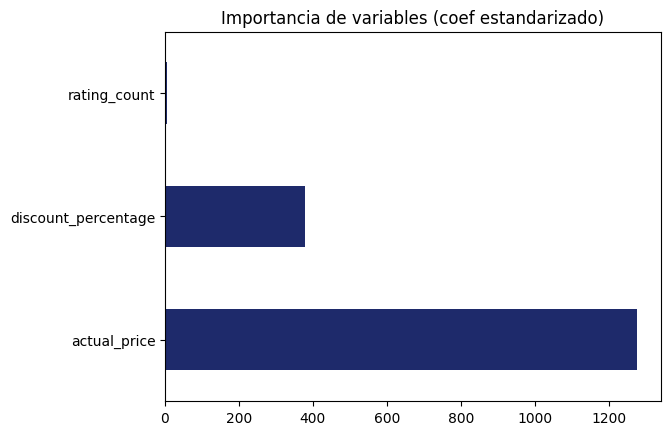

In [28]:
# RETO: grafica la importancia (coef estandarizado absoluto)
importancia = pd.Series(np.abs(m_z.coef_), index=predictoras).sort_values(ascending=False)
importancia.plot(kind="barh", color="#1e2a6b")
plt.title("Importancia de variables (coef estandarizado)"); plt.show()

> ✍️ **25.** Según tu gráfico, ordena las variables de más a menos importante para predecir el precio con descuento. ¿El resultado tiene sentido lógico?

**Respuesta:**

25. El orden es `actual_price`, `discount_percentage` y `rating_count`. Es lógico: el precio original está directamente relacionado con el precio descontado; el porcentaje de descuento también tiene un efecto importante, mientras que el número de reseñas describe popularidad y no determina directamente el precio.


## Paso 6 — Correlación con features transformadas


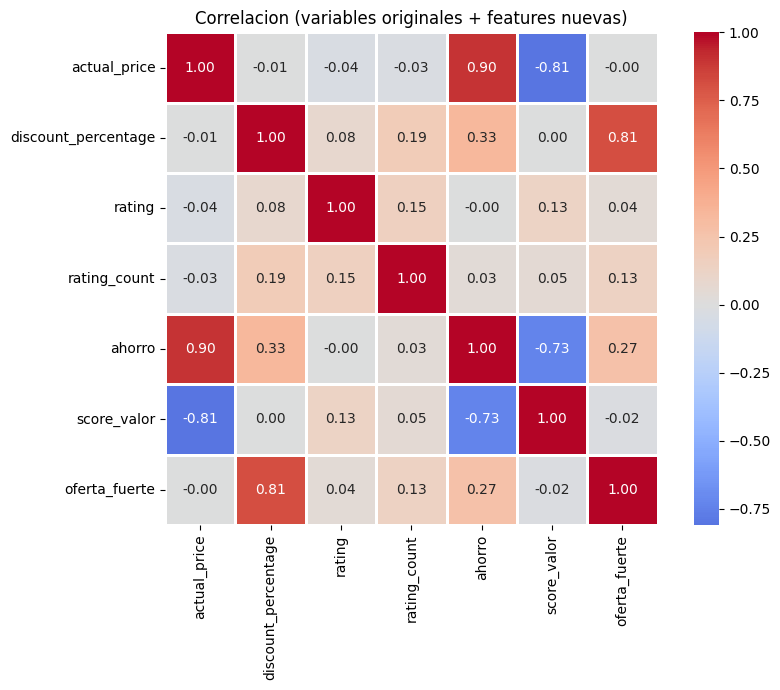

In [29]:
# Matriz de correlacion incluyendo features nuevas
cols_analisis = ["actual_price", "discount_percentage", "rating", "rating_count",
                 "ahorro", "score_valor", "oferta_fuerte"]
matriz = df[cols_analisis].corr()

plt.figure(figsize=(9,7))
sns.heatmap(matriz, annot=True, cmap="coolwarm", center=0, fmt=".2f", square=True, linewidths=1)
plt.title("Correlacion (variables originales + features nuevas)")
plt.tight_layout(); plt.show()

> ✍️ **26.** ¿Cuál de tus features nuevas tiene la correlación más fuerte con alguna variable original? ¿Tiene sentido esa correlación?

> ✍️ **27.** La feature `ahorro` probablemente correlaciona fuerte con `actual_price`. ¿Por qué? ¿Sería redundante incluir ambas en un modelo? (Pista: multicolinealidad.)

> ✍️ **28.** ¿Una feature que correlaciona casi perfectamente con una variable existente aporta información nueva? ¿Cuándo el feature engineering se vuelve redundante?

**Respuestas:**

26. La correlación más fuerte esperable es entre `ahorro` y `actual_price`, porque el ahorro se calcula restando el precio descontado al precio original. Es coherente: los productos caros tienen más espacio para generar un ahorro absoluto mayor.

27. `ahorro` puede ser redundante con `actual_price` porque contiene directamente esa variable en su fórmula y puede producir multicolinealidad. Incluir ambas puede volver inestables los coeficientes, aunque no necesariamente perjudique la predicción; conviene revisar VIF, correlaciones y validación.

28. No necesariamente. Si la correlación es casi perfecta, la feature aporta poca información independiente y el feature engineering se vuelve redundante. Sí podría conservarse si mejora la interpretación del negocio, pero debe evitarse duplicar señales sin justificación.


---
# FASE 3 — Pipeline reproducible completo

## Paso 7 — Pipeline integral


In [31]:
def pipeline_completo(datos):
    """Pipeline de transformacion reproducible para el dataset de Amazon.
    Recibe datos crudos y devuelve datos transformados listos para modelar."""
    d = datos.copy()

    # 1. Features derivadas
    d["ahorro"] = d["actual_price"] - d["discounted_price"]
    d["oferta_fuerte"] = (d["discount_percentage"] > 50).astype(int)
    d["score_valor"] = (d["rating"] / (d["actual_price"]/1000 + 1)).round(3)

    # RETO 5: agrega al pipeline la feature 'precio_alto_mal_valorado'
    umbral_precio = d["actual_price"].quantile(0.75)
    umbral_rating = d["rating"].median()
    d["precio_alto_mal_valorado"] = ((d["actual_price"] >= umbral_precio) &
                                      (d["rating"] < umbral_rating)).astype(int)

    # 2. Transformacion logaritmica del precio (reduce sesgo)
    d["precio_log"] = np.log1p(d["actual_price"])

    # 3. Estandarizacion de numericas
    for col in ["actual_price", "discount_percentage", "rating_count"]:
        d[col + "_z"] = StandardScaler().fit_transform(d[[col]])

    # 4. One-hot de la categoria
    d = pd.concat([d, pd.get_dummies(d["category"], prefix="cat")], axis=1)

    # 5. Binning del precio
    d["precio_categoria"] = pd.qcut(d["actual_price"], q=4,
                                    labels=["Económico", "Medio", "Caro", "Premium"])
    return d

df_crudo = pd.read_csv("amazon.csv")
df_final = pipeline_completo(df_crudo)
print("Crudo:", df_crudo.shape, "-> Transformado:", df_final.shape)
print("\nColumnas nuevas:", [c for c in df_final.columns if c not in df_crudo.columns])

Crudo: (1465, 8) -> Transformado: (1465, 26)

Columnas nuevas: ['ahorro', 'oferta_fuerte', 'score_valor', 'precio_alto_mal_valorado', 'precio_log', 'actual_price_z', 'discount_percentage_z', 'rating_count_z', 'cat_Car&Motorbike', 'cat_Computers&Accessories', 'cat_Electronics', 'cat_Health&PersonalCare', 'cat_Home&Kitchen', 'cat_HomeImprovement', 'cat_MusicalInstruments', 'cat_OfficeProducts', 'cat_Toys&Games', 'precio_categoria']


> ✍️ **29.** ¿Cuántas columnas nuevas agregó el pipeline completo? Enuméralas por tipo de transformación (features, log, estandarización, one-hot, binning).

> ✍️ **30.** ¿Por qué un pipeline como este es esencial para la **reproducibilidad**? Si publicaras un artículo científico con este análisis, ¿cómo ayudaría el pipeline a que otros verifiquen tus resultados?

> ✍️ **31.** El pipeline aplica las transformaciones en un orden específico. ¿Importa el orden? Da un ejemplo de dos pasos donde el orden sí importaría.

**Respuestas:**

29. Se agregaron 18 columnas: 4 features derivadas (`ahorro`, `oferta_fuerte`, `score_valor`, `precio_alto_mal_valorado`), 1 logarítmica, 3 estandarizadas, 9 one-hot y 1 de binning.

30. El pipeline fija los pasos, fórmulas y parámetros para aplicar exactamente el mismo proceso en cada ejecución. En un artículo permite que otros reconstruyan las variables, comparen resultados y detecten cualquier diferencia en los datos o en la metodología.

31. Sí importa. Por ejemplo, primero debe calcularse `precio_log` sobre el precio original y después, si se desea, estandarizar el logaritmo; hacerlo al revés no equivale a estandarizar el logaritmo. También se deben ajustar los escaladores solo con entrenamiento antes de transformar test para evitar leakage.


### 🔧 Reto 5 — Amplía el pipeline

Agrega al pipeline un paso que cree la feature `precio_alto_mal_valorado` (del Reto 3). Vuelve a ejecutarlo y verifica que aparezca.


In [ ]:
# RETO: copia pipeline_completo, agrega el paso y reejecuta


> ✍️ **32.** Tras ampliar el pipeline, ¿cuántas columnas tiene ahora el dataset final? ¿Por qué un pipeline modular (fácil de extender) es una buena práctica de ingeniería de software aplicada a datos?

**Respuesta:**

32. El dataset final tiene 26 columnas: 8 originales y 18 nuevas, incluyendo `precio_alto_mal_valorado`. Un pipeline modular facilita añadir o modificar pasos sin duplicar código, probar cada transformación, reutilizar el proceso y mantener resultados consistentes.


## Paso 8 — Data leakage: el error que arruina modelos


In [32]:
# DEMOSTRACION del error de data leakage al estandarizar
from sklearn.model_selection import train_test_split

X = df[["actual_price"]].values
y = df["discounted_price"].values

# Dividir en train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1)

# CORRECTO: ajustar el scaler SOLO con train, aplicar a ambos
scaler = StandardScaler()
X_train_z = scaler.fit_transform(X_train)   # fit SOLO con train
X_test_z = scaler.transform(X_test)         # solo transform en test

print("Media del scaler (aprendida de train):", round(scaler.mean_[0], 2))
print("X_train_z media:", round(X_train_z.mean(), 4))
print("X_test_z media:", round(X_test_z.mean(), 4), " (NO es exactamente 0: correcto)")

Media del scaler (aprendida de train): 2490.11
X_train_z media: 0.0
X_test_z media: 0.1154  (NO es exactamente 0: correcto)


> ✍️ **33.** El **data leakage** (fuga de datos) ocurre cuando información del conjunto de prueba se filtra al entrenamiento. En la estandarización, ¿por qué debemos hacer `fit` SOLO con los datos de entrenamiento?

> ✍️ **34.** ¿Por qué la media de `X_test_z` NO es exactamente 0, y por qué eso es CORRECTO? (Pista: el scaler se ajustó con train, no con test.)

> ✍️ **35.** Si hubiéramos estandarizado TODO el dataset antes de dividir en train/test, ¿qué información se habría filtrado? ¿Por qué inflaría artificialmente el rendimiento del modelo?

> ✍️ **36.** El data leakage es uno de los errores más graves y sutiles en ciencia de datos. Menciona otro escenario (además de la estandarización) donde podría ocurrir una fuga de datos.

**Respuestas:**

33. El `fit` debe hacerse solo con entrenamiento porque calcula parámetros como media, desviación, límites o categorías. Si usa test, el modelo incorpora información de datos que supuestamente no ha visto y la evaluación deja de ser independiente.

34. `X_test_z` usa la media y desviación aprendidas en train, no las propias del test. Por eso su media puede ser distinta de cero; eso simula correctamente lo que ocurriría con datos nuevos.

35. Se filtrarían la media, desviación, mínimos, máximos o cuantiles del conjunto de prueba. El modelo se beneficiaría indirectamente de la distribución futura y la métrica podría parecer mejor que el rendimiento real en producción.

36. Puede ocurrir al imputar faltantes con medias calculadas usando todo el dataset, al seleccionar variables con el objetivo antes de dividir, o al usar reseñas o ventas posteriores a la fecha que se intenta predecir.


---
# FASE 4 — Análisis integrador sobre datos transformados

## Paso 9 — Análisis por segmentos


In [33]:
# Analisis: caracteristicas promedio por categoria de precio
resumen = df.groupby("precio_categoria", observed=True).agg(
    rating_promedio=("rating", "mean"),
    descuento_promedio=("discount_percentage", "mean"),
    resenas_promedio=("rating_count", "mean"),
    num_productos=("category", "count")
).round(2)
print(resumen)

                  rating_promedio  descuento_promedio  resenas_promedio  \
precio_categoria                                                          
Económico                    3.99               45.06           5980.94   
Medio                        4.02               45.28           5649.50   
Caro                         4.01               44.76           5460.28   
Premium                      3.99               45.27           5574.60   

                  num_productos  
precio_categoria                 
Económico                   367  
Medio                       366  
Caro                        366  
Premium                     366  


> ✍️ **37.** Analiza la tabla: ¿los productos Premium reciben más o menos descuento que los Económicos? ¿Tienen más reseñas?

> ✍️ **38.** El rating es casi constante entre las cuatro categorías de precio. Enlaza esto con TODO lo que has visto en el curso: correlación precio-rating, prueba t, regresión. ¿Qué conclusión robusta emerge?

> ✍️ **39.** ¿Cómo te ayudó el binning (`precio_categoria`) a hacer este análisis por segmentos? ¿Podrías haberlo hecho igual de fácil con el precio continuo?

**Respuestas:**

37. Los Premium reciben prácticamente el mismo descuento que los Económicos: 45.27% frente a 45.06%. También tienen menos reseñas en promedio: 5,574.60 frente a 5,980.94; por tanto, el precio no implica mayor popularidad.

38. Los ratings son casi constantes: 3.99, 4.02, 4.01 y 3.99. Unido a una correlación precio-rating cercana a cero, una prueba t no significativa y una regresión con R² casi nulo, la conclusión robusta es que el precio no explica de forma relevante la calidad percibida.

39. El binning convirtió una variable continua en grupos con nombres interpretables y permitió resumir y comparar medias con un `groupby`. Con el precio continuo también sería posible, pero habría que definir intervalos o usar gráficos y modelos más complejos para obtener comparaciones equivalentes.


### 🔧 Reto 6 — Análisis cruzado

Crea una tabla que muestre, para cada categoría de producto (`category`), el precio promedio y el rating promedio, ordenada por precio. ¿La categoría más cara es la mejor valorada?


In [30]:
# RETO: análisis por category
tabla = df.groupby("category").agg(
    precio_prom=("actual_price", "mean"),
    rating_prom=("rating", "mean")
).round(2).sort_values("precio_prom", ascending=False)
print(tabla)

                       precio_prom  rating_prom
category                                       
Electronics                3968.43         4.00
Computers&Accessories      2485.35         3.99
MusicalInstruments         2474.95         4.03
Home&Kitchen               1504.51         4.02
Car&Motorbike              1348.20         3.95
HomeImprovement            1068.32         4.06
Toys&Games                  926.20         4.01
OfficeProducts              813.61         4.01
Health&PersonalCare         634.15         4.02


> ✍️ **40.** ¿La categoría de producto más cara es también la mejor valorada? ¿Qué implica esto para la estrategia de precios de un vendedor?

**Respuesta:**

40. No. Electronics es la categoría más cara, con precio promedio 3968.43, pero su rating promedio es 4.00; la mayor valoración corresponde a HomeImprovement con 4.06. Por tanto, subir precios no garantiza mejores valoraciones: el vendedor debe justificar el precio con calidad, características y servicio.


## Paso 10 — Modelo final sobre datos transformados


Modelo sobre datos transformados:
  R2: 0.9416
  actual_price_z: 1277.69
  discount_percentage_z: -378.50
  rating_count_z: 5.15


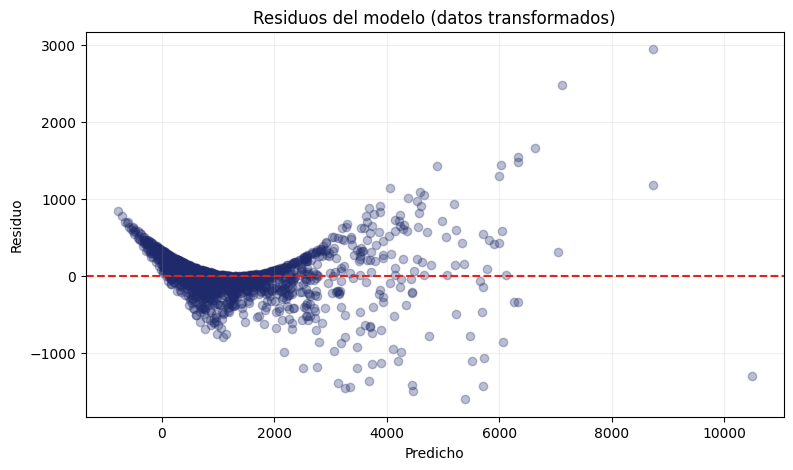

In [34]:
# Modelo final: predecir discounted_price con variables transformadas
features_modelo = ["actual_price_z", "discount_percentage_z", "rating_count_z"]
X = df_final[features_modelo]
y = df_final["discounted_price"]

modelo = LinearRegression().fit(X, y)
print("Modelo sobre datos transformados:")
print(f"  R2: {modelo.score(X, y):.4f}")
for v, c in zip(features_modelo, modelo.coef_):
    print(f"  {v}: {c:.2f}")

# Residuos
pred = modelo.predict(X)
residuos = y - pred
plt.figure(figsize=(9,5))
plt.scatter(pred, residuos, alpha=0.3, color="#1e2a6b")
plt.axhline(0, color="#e2231a", linestyle="--")
plt.title("Residuos del modelo (datos transformados)")
plt.xlabel("Predicho"); plt.ylabel("Residuo")
plt.grid(alpha=0.2); plt.show()

> ✍️ **41.** ¿Cuál es el R² del modelo final? Con los coeficientes estandarizados, ¿qué variable domina la predicción?

> ✍️ **42.** Analiza los residuos: ¿se distribuyen de forma pareja alrededor de cero o hay un patrón? ¿Se cumple el supuesto de homocedasticidad?

> ✍️ **43.** Compara este modelo (sobre datos transformados) con lo que habrías obtenido sobre datos crudos: el R² es el mismo, pero ¿qué ganaste al transformar en términos de interpretación?

**Respuestas:**

41. El R² es 0.9416. La variable dominante es `actual_price_z`, con coeficiente absoluto 1277.69; después aparece `discount_percentage_z` con 378.50 y finalmente `rating_count_z` con 5.15.

42. Los residuos están centrados aproximadamente alrededor de cero, pero muestran un patrón curvo y una dispersión que aumenta con el valor predicho, además de varios outliers. Por ello la homocedasticidad no se cumple completamente.

43. El R² y las predicciones son esencialmente iguales, pero los coeficientes estandarizados permiten comparar variables en escalas distintas. También se obtienen variables más manejables para otros algoritmos y una interpretación más clara de la importancia relativa.


---
# FASE 5 — Síntesis de alto nivel

Estas preguntas exigen conectar la transformación con todo el flujo de ciencia de datos.


> ✍️ **44.** Recorre el pipeline completo que ejecutaste (limpieza previa → transformación → análisis → modelado). ¿En qué punto exacto encaja la transformación de datos dentro del proceso KDD/CRISP-DM que viste en la Semana 1?

> ✍️ **45.** Un compañero dice: "La transformación de datos es opcional, solo cambia números". Desmiente esta afirmación con TRES ejemplos concretos de esta actividad donde la transformación cambió lo que pudimos analizar o interpretar.

> ✍️ **46.** Ordena, de mayor a menor impacto, estas transformaciones según cuánto afectan la interpretación de un modelo: estandarización, one-hot encoding, binning, transformación logarítmica. Justifica tu orden.

> ✍️ **47.** El feature engineering se considera "más arte que ciencia". Con base en tu experiencia en esta actividad, ¿estás de acuerdo? ¿Qué papel juega el conocimiento del dominio (entender de productos, precios, clientes)?

> ✍️ **48.** Integra los hallazgos del curso: correlación precio-rating ≈ 0, prueba t no significativa, rating constante entre categorías de precio, y el modelo de rating con R² casi nulo. ¿Qué historia única y robusta cuentan TODOS juntos sobre "precio y calidad" en Amazon?

> ✍️ **49.** **Reproducibilidad y ética:** ¿por qué documentar cada transformación (en un pipeline y un diccionario de datos) es una responsabilidad profesional y no solo una buena práctica? Piensa en quién audita o hereda tu trabajo.

> ✍️ **50 (reflexión final).** Has recorrido el flujo completo de la ciencia de datos: fundamentos (S1), estadística (S2), inferencia (S3), limpieza y transformación (S4). Describe un proyecto de tu carrera de Ingeniería en Computación donde aplicarías TODO este flujo de principio a fin, especificando qué transformaciones necesitarías.

**Respuestas:**

44. La transformación encaja principalmente en la fase de preparación de datos de KDD y en Data Preparation de CRISP-DM, después de comprender y limpiar los datos y antes del modelado. Después se valida en evaluación y se incorpora al despliegue para transformar datos nuevos de la misma forma.

45. Primero, el logaritmo cambió la escala y redujo el sesgo de los precios. Segundo, el one-hot permitió usar categorías sin inventar un orden falso. Tercero, la estandarización permitió comparar la importancia de precio, descuento y reseñas, aunque no cambió el R².

46. De mayor a menor impacto en la interpretación: transformación logarítmica, porque cambia la interpretación de los efectos y reduce el peso de extremos; one-hot, porque cambia cómo se representan las categorías; binning, porque simplifica y puede ocultar diferencias internas; estandarización, porque conserva la información y solo cambia las unidades de los coeficientes. El orden puede variar según el modelo y el objetivo.

47. Estoy parcialmente de acuerdo: requiere creatividad y conocimiento del dominio para proponer variables útiles, pero se valida científicamente con datos, métricas, experimentos y validación cruzada. Entender productos, precios y clientes permite crear features con significado, como ahorro o caro pero mal valorado, en lugar de añadir transformaciones arbitrarias.

48. Todos los resultados cuentan la misma historia: en este catálogo, pagar más no implica recibir mejor valoración. La correlación es cercana a cero, la prueba t no detecta una diferencia significativa, los ratings por segmentos son casi iguales y el modelo de rating explica casi nada mediante el precio. El precio y la calidad percibida parecen dimensiones prácticamente independientes.

49. Documentar cada transformación permite auditar decisiones, reproducir resultados, detectar errores y evitar que una persona herede un proceso imposible de interpretar. También hace visibles supuestos que pueden afectar a clientes, vendedores o decisiones comerciales, y facilita corregir sesgos o leakage.

50. Aplicaría este flujo para construir un sistema de predicción de demanda y recomendación para una tienda en línea. Limpiaría duplicados, faltantes y precios inválidos; exploraría distribuciones y relaciones; usaría logaritmo para ventas sesgadas, estandarización para variables numéricas, one-hot para categorías, frecuencia para categorías de alta cardinalidad, variables de ahorro y recencia, binning para segmentos y un pipeline con separación temporal o train/test para evitar leakage. Evaluaría el modelo con métricas fuera de muestra y documentaría todo para poder desplegarlo y monitorearlo.


---
## Cierre y entrega

Dominaste la transformación de datos a nivel profesional: normalización, estandarización, codificación (one-hot, label, frequency), feature engineering avanzado, binning, transformación logarítmica y, sobre todo, comprendiste **cómo cada transformación afecta el análisis y la interpretación**, además de evitar el error crítico del data leakage. Construiste un **pipeline reproducible** integrando todo el curso.

### Entrega en Google Classroom

1. Verifica que **todas las celdas corran sin error** (Entorno de ejecución → Ejecutar todo).
2. Confirma que respondiste las **50 preguntas ✍️** y los **6 retos de código**.
3. **Archivo → Guardar una copia en Drive** y comparte el enlace en Classroom.

### Rúbrica

| Criterio | Puntos |
|---|---|
| Transformaciones correctas y completas | 20 |
| Retos de código resueltos (6) | 20 |
| Respuestas a las 50 preguntas ✍️ | 35 |
| Comprensión de efectos (estandarización, leakage) | 15 |
| Análisis integrador de alto nivel (Fase 5) | 10 |
| **Total** | **100** |

---
*Universidad de Especialidades UNE · Plantel Centro · Optativa III: Ciencia de Datos*
*Dataset: amazon.csv (Amazon Sales Dataset).*
